In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fsps

from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
from astropy.constants import c, L_sun

from hubersed.fitting.chi2 import load_by_index, tids_to_indices, WAVE_OBS, flambda_to_maggies, ivar_flambda_to_ivar_maggies

/Users/ng27753/Astronomy_Research/hubersed/.venv/lib/python3.13/site-packages/prospect/sources/fake_fsps.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
from scipy.integrate import cumulative_trapezoid

def ssfr_from_tabular_sfh(age_vals, sfr_vals):
    # sSFR(t) = SFR(t) / M_formed(<t). age_vals: Gyr since Big Bang, sfr_vals: Msun/yr.
    age_yr = age_vals * 1e9
    mass_cum = np.concatenate([[0.0], cumulative_trapezoid(sfr_vals, age_yr)])
    ssfr = np.full_like(sfr_vals, np.nan, dtype=float)
    nonzero = mass_cum > 0
    ssfr[nonzero] = sfr_vals[nonzero] / mass_cum[nonzero]
    return ssfr

def plot_ssfr(age_vals, sfr_vals, title=""):
    ssfr = ssfr_from_tabular_sfh(age_vals, sfr_vals)
    plt.figure(figsize=(8, 5))
    plt.step(age_vals, ssfr, where="post", marker="o")
    plt.yscale("log")
    plt.xlabel("Age since Big Bang [Gyr]")
    plt.ylabel(r"sSFR(t) [yr$^{-1}$]")
    plt.title(title)


In [3]:
TARGETID = 39633140817331167
gidx = tids_to_indices(np.array([TARGETID]))[0]
spec, ivar, z, tid_chunk = load_by_index(gidx)
assert tid_chunk == TARGETID, f"Loaded TARGETID {tid_chunk} does not match requested TARGETID {TARGETID}"

flux =  flambda_to_maggies(WAVE_OBS, spec)
ivm =   ivar_flambda_to_ivar_maggies(WAVE_OBS, ivar)
good = (ivm > 0) & (flux > 0) & np.isfinite(flux)
unc  = 1/np.sqrt(np.where(ivm > 0, ivm, np.inf))

D_L = cosmo.luminosity_distance(z).to(u.cm).value

In [4]:
t_univ = cosmo.age(z).to_value(u.Gyr)

age_bins = np.zeros((15, 2))
age_bins[0] = [0.001, 0.005]
age_bins[1] = [0.005, 0.01]
log_t_edges = np.geomspace(0.01, 0.95 * t_univ, 14)   # 14 edges -> 13 bins (was 9 -> 8)
for i in range(2, 15):
    age_bins[i] = [log_t_edges[i - 2], log_t_edges[i - 1]]

# flip lookback-time bin edges -> forward age since Big Bang, as before
edges_lookback = np.unique(age_bins)
maxage = edges_lookback.max()
age = np.sort(maxage - edges_lookback)

print(f"{len(age)} points, {len(age)-1} bins")
print(np.round(age, 5))

# sfr at each age, Msun/yr, no negative and value > 1e-33
sfr = np.array([0.01, 10.0, 1.5, 5.0, 2.0, 8.0, 1.0, 0.5, 4.0, 0.2, 1.0, 0.1, 0.05, 0.01, 0.005, 0.01])  # Msun/yr


# mass formed (Msun) is what I put in.
mass_formed = np.trapz(sfr, age)  # Msun
print(f"Total mass formed: {mass_formed:.2e} Msun")

16 points, 15 bins
[ 0.       5.43836  8.57408 10.38211 11.42461 12.0257  12.37229 12.57212
 12.68735 12.75379 12.7921  12.81418 12.82692 12.83426 12.83926 12.84326]
Total mass formed: 5.99e+01 Msun


/var/folders/4v/k4xpjdyx3f1_c95lc_dlyhkr0000gq/T/ipykernel_48643/746822432.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mass_formed = np.trapz(sfr, age)  # Msun


In [5]:
sp = fsps.StellarPopulation(
    sfh=3,
    zcontinuous=1,
    logzsol=0.0,
)

dust2 = 0.13165773
dust_ratio = 0.87079155
dust1 = dust2 * dust_ratio   # FSPS has no dust_ratio param -- it's hubersed/Prospector-side

sp = fsps.StellarPopulation(
    sfh=3,
    zcontinuous=1,
    add_neb_emission=True,   # required for gas_logz/gas_logu to matter
)

sp.params["logzsol"]     = 0.24999979
sp.params["dust_type"]   = 4          # Kriek & Conroy 2013, hubersed's fixed choice (config.py:105)
sp.params["dust2"]       = dust2
sp.params["dust1"]       = dust1
sp.params["dust_index"]  = -2.32386258
sp.params["gas_logz"]    = 0.32816795
sp.params["gas_logu"]    = -3.40446795
sp.params["sigma_smooth"] = 151.33225551

sp.set_tabular_sfh(age, sfr)

In [6]:
# get the final composite spectrum at final age of 13.7 Gyr
wave_rest, spec = sp.get_spectrum(tage=13.7,)
wave_obs = wave_rest * (1 + z)

# mask to only DESI's observed wavelength range
mask = (wave_obs >= WAVE_OBS.min()) & (wave_obs <= WAVE_OBS.max())
wave_sub, spec_sub = wave_obs[mask], spec[mask]

# Lsun/Hz (rest) -> erg/s/Hz -> observed f_nu -> maggies
Lsun_cgs = 3.839e33  # FSPS's internal solar luminosity const, fsps/src/sps_vars.f90:357
FNU_PER_MAGGIE = 3631e-23  # erg/s/cm^2/Hz

L_nu_cgs = spec_sub * Lsun_cgs
f_nu = L_nu_cgs * (1.0 + z) / (4.0 * np.pi * D_L**2)  # erg/s/cm^2/Hz
maggies_sub = f_nu / FNU_PER_MAGGIE

In [7]:
# resample FSPS model onto DESI's fixed WAVE_OBS grid
model_on_desi = np.interp(WAVE_OBS, wave_sub, maggies_sub)

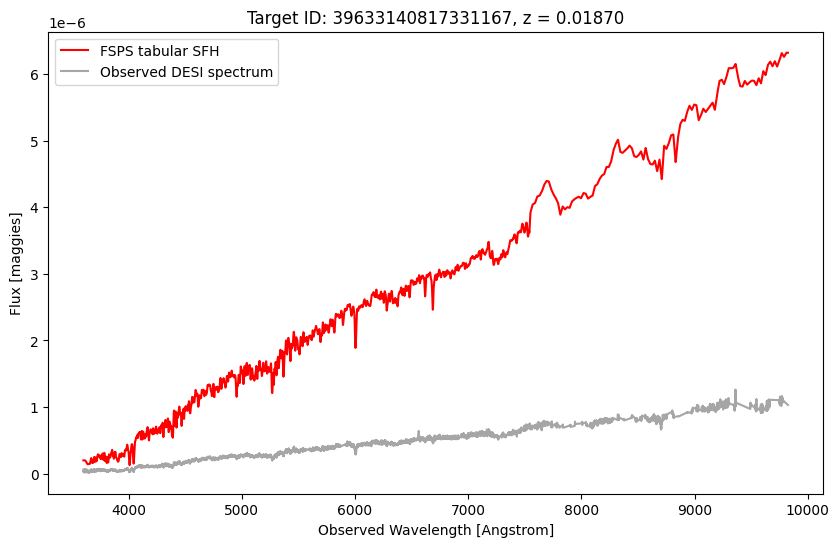

In [8]:
# let's plot the spectrum
plt.figure(figsize=(10, 6))

# plt.plot(wave_sub, maggies_sub, label='FSPS tabular SFH', color='red')

# use the model resampled onto DESI's WAVE_OBS grid for plotting
plt.plot(WAVE_OBS, model_on_desi, label='FSPS tabular SFH', color='red')

# DESI Observed spectrum
plt.plot(WAVE_OBS[good], flux[good], label='Observed DESI spectrum', color='gray', alpha=0.7)

plt.xlabel('Observed Wavelength [Angstrom]')
plt.ylabel('Flux [maggies]')
plt.title(f'Target ID: {TARGETID}, z = {z:.5f}')
plt.legend()

In [9]:
from scipy.optimize import minimize

def model_maggies(sfr_vals, age_vals=age):
    sp.set_tabular_sfh(age_vals, sfr_vals)
    wave_rest, spec = sp.get_spectrum(tage=age_vals.max())
    wave_obs_model = wave_rest * (1 + z)

    L_nu_cgs = spec * Lsun_cgs
    f_nu = L_nu_cgs * (1.0 + z) / (4.0 * np.pi * D_L**2)
    maggies = f_nu / FNU_PER_MAGGIE

    return np.interp(WAVE_OBS, wave_obs_model, maggies)

def neg_lnlike(sfr_vals, age_vals=age):
    model = model_maggies(sfr_vals, age_vals)
    resid = (model[good] - flux[good]) * np.sqrt(ivm[good])
    return np.sum(resid**2)

bounds = [(1e-17, None)] * len(age)
res = minimize(neg_lnlike, sfr, method='L-BFGS-B', bounds=bounds)

sfr_opt = res.x
print(f"success={res.success}, chi2={res.fun:.2f}, npix={good.sum()}")

success=True, chi2=26004.96, npix=5840


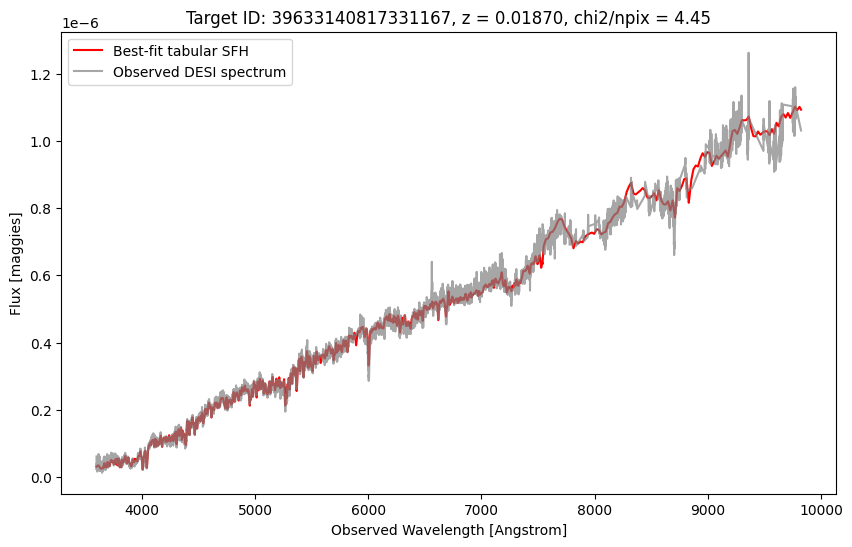

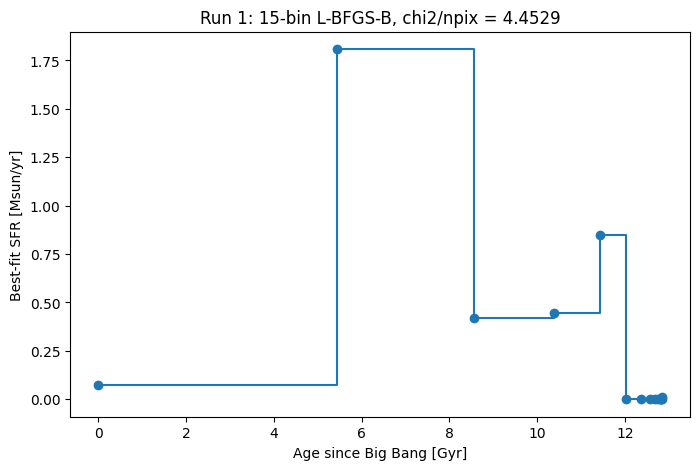

In [10]:
import os
os.makedirs('figures', exist_ok=True)

model_best = model_maggies(sfr_opt)

plt.figure(figsize=(10, 6))
plt.plot(WAVE_OBS, model_best, label='Best-fit tabular SFH', color='red')
plt.plot(WAVE_OBS[good], flux[good], label='Observed DESI spectrum', color='gray', alpha=0.7)
plt.xlabel('Observed Wavelength [Angstrom]')
plt.ylabel('Flux [maggies]')
plt.title(f'Target ID: {TARGETID}, z = {z:.5f}, chi2/npix = {res.fun/good.sum():.2f}')
plt.legend()
plt.savefig('figures/run1_15bin_lbfgsb_bestfit.png', dpi=150, bbox_inches='tight')


plt.figure(figsize=(8, 5))
plt.step(age, sfr_opt, where='post', marker='o')
plt.xlabel('Age since Big Bang [Gyr]')
plt.ylabel('Best-fit SFR [Msun/yr]')
plt.title(f'Run 1: 15-bin L-BFGS-B, chi2/npix = {res.fun/good.sum():.4f}')
plt.savefig('figures/run1_15bin_lbfgsb_sfr.png', dpi=150, bbox_inches='tight')

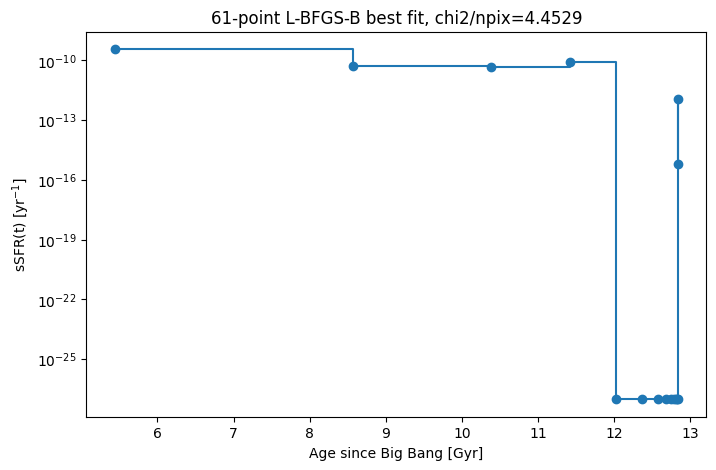

In [11]:
plot_ssfr(age, sfr_opt, title=f"61-point L-BFGS-B best fit, chi2/npix={res.fun/good.sum():.4f}")


In [12]:
sfr_opt

array([7.33397996e-02, 1.80810381e+00, 4.20041332e-01, 4.46402603e-01,
       8.48371490e-01, 1.00000000e-17, 1.00000000e-17, 1.00000000e-17,
       1.00000000e-17, 1.00000000e-17, 1.00000000e-17, 1.00000000e-17,
       1.00000000e-17, 1.00000000e-17, 1.14627501e-02, 6.31868776e-06])

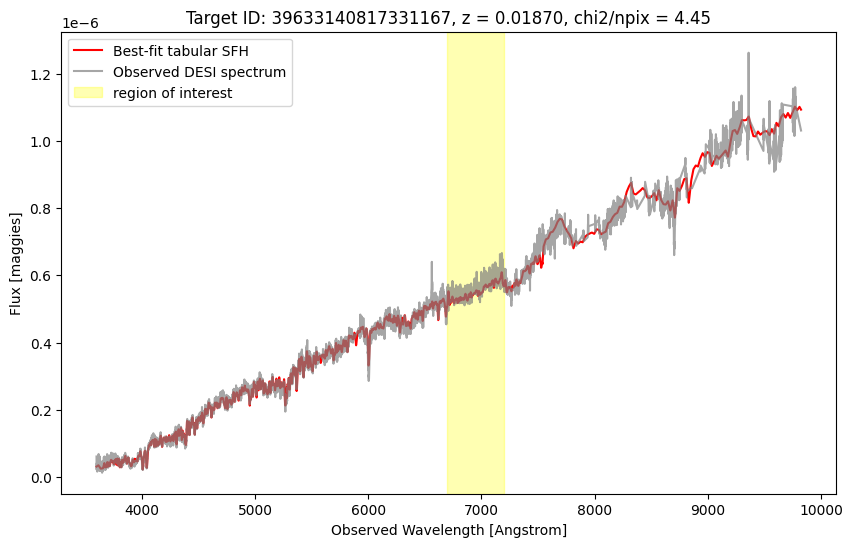

In [13]:
model_best = model_maggies(sfr_opt)

plt.figure(figsize=(10, 6))
plt.plot(WAVE_OBS, model_best, label='Best-fit tabular SFH', color='red')
plt.plot(WAVE_OBS[good], flux[good], label='Observed DESI spectrum', color='gray', alpha=0.7)

# vertical range
plt.axvspan(xmin=6700, xmax=7200, color='yellow', alpha=0.3, label='region of interest')

plt.xlabel('Observed Wavelength [Angstrom]')
plt.ylabel('Flux [maggies]')
plt.title(f'Target ID: {TARGETID}, z = {z:.5f}, chi2/npix = {res.fun/good.sum():.2f}')
plt.legend()


In [14]:
region_mask = (WAVE_OBS >= 6700) & (WAVE_OBS <= 7200)

base = model_maggies(sfr_opt)
sens = np.zeros(len(sfr_opt))
for i in range(len(sfr_opt)):
    sfr_pert = sfr_opt.copy()
    sfr_pert[i] = sfr_pert[i] * 1.1 + 1e-8   # small relative bump, +eps guards true zeros
    d = model_maggies(sfr_pert) - base
    sens[i] = np.sum(d[region_mask]**2)      # response power in the region of interest

order = np.argsort(sens)[::-1]
for i in order[:5]:
    print(f"bin {i}: age={age[i]:.3f} Gyr, sfr={sfr_opt[i]:.4g}, sensitivity={sens[i]:.3e}")


bin 1: age=5.438 Gyr, sfr=1.808, sensitivity=5.925e-13
bin 4: age=11.425 Gyr, sfr=0.8484, sensitivity=8.003e-14
bin 2: age=8.574 Gyr, sfr=0.42, sensitivity=2.454e-14
bin 3: age=10.382 Gyr, sfr=0.4464, sensitivity=2.296e-14
bin 0: age=0.000 Gyr, sfr=0.07334, sensitivity=2.327e-16


In [15]:
eps = 1e-3
nbin = len(sfr_opt)
base = model_maggies(sfr_opt)

J = np.zeros((nbin, len(WAVE_OBS)))   # Jacobian: dmodel/dsfr_i
for i in range(nbin):
    sfr_pert = sfr_opt.copy()
    step = max(sfr_pert[i] * eps, 1e-6)
    sfr_pert[i] += step
    J[i] = (model_maggies(sfr_pert) - base) / step

F = np.zeros((nbin, nbin))
for i in range(nbin):
    for j in range(nbin):
        F[i, j] = np.sum(J[i, good] * J[j, good] * ivm[good])

cov = np.linalg.pinv(F)   # pinv: F is often near-singular for tabular SFH
sigma = np.sqrt(np.abs(np.diag(cov)))
corr = cov / np.outer(sigma, sigma)

print("1-sigma uncertainty per bin:", sigma)
print("\ncorrelation of bin 1 with all others:")
for i in range(nbin):
    print(f"  bin {i} (age={age[i]:.3f}): corr={corr[1, i]:.3f}")

1-sigma uncertainty per bin: [2.46370581 2.54862031 2.31645983 1.152496   0.84471456 0.66658484
 0.53604766 0.58852693 0.93780214 1.50367363 1.74146663 1.14741265
 0.54462105 0.19775859 0.02675607 0.02163339]

correlation of bin 1 with all others:
  bin 0 (age=0.000): corr=-0.980
  bin 1 (age=5.438): corr=1.000
  bin 2 (age=8.574): corr=-0.940
  bin 3 (age=10.382): corr=0.485
  bin 4 (age=11.425): corr=0.294
  bin 5 (age=12.026): corr=-0.402
  bin 6 (age=12.372): corr=0.399
  bin 7 (age=12.572): corr=-0.326
  bin 8 (age=12.687): corr=0.230
  bin 9 (age=12.754): corr=-0.085
  bin 10 (age=12.792): corr=0.074
  bin 11 (age=12.814): corr=-0.229
  bin 12 (age=12.827): corr=0.224
  bin 13 (age=12.834): corr=0.236
  bin 14 (age=12.839): corr=-0.304
  bin 15 (age=12.843): corr=0.295


In [16]:
extra = np.linspace(age[0], age[2], 6)[1:-1]   # 4 new points between bin0 and bin2, straddling bin1
age_refined = np.sort(np.unique(np.concatenate([age, extra])))
sfr_refined = np.interp(age_refined, age, sfr_opt)   # warm-start from current best fit

print(f"{len(age_refined)} points now")

bounds = [(1e-17, None)] * len(age_refined)
res2 = minimize(lambda s: neg_lnlike(s, age_refined), sfr_refined, method='L-BFGS-B', bounds=bounds)
print(f"success={res2.success}, chi2={res2.fun:.2f}, npix={good.sum()}")

20 points now


success=True, chi2=25924.14, npix=5840


In [17]:
age_coarse = np.concatenate([[age[0], age[2]], age[3:]])
merged_val = np.trapz(sfr_opt[:3], age[:3]) / (age[2] - age[0])
sfr_coarse =  np.concatenate([[merged_val, merged_val], sfr_opt[3:]])
bounds = [(1e-17, None)] * len(age_coarse)
res3 = minimize(lambda s: neg_lnlike(s, age_coarse), sfr_coarse, method='L-BFGS-B', bounds=bounds)
print(f"success={res3.success}, chi2={res3.fun:.2f}, npix={good.sum()}")

/var/folders/4v/k4xpjdyx3f1_c95lc_dlyhkr0000gq/T/ipykernel_48643/678200206.py:2: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  merged_val = np.trapz(sfr_opt[:3], age[:3]) / (age[2] - age[0])


success=True, chi2=26057.41, npix=5840


In [18]:
eigval, eigvec = np.linalg.eigh(F)
order = np.argsort(eigval)[::-1]

print("best-constrained combination of bins (largest Fisher eigenvalue):")
for i, coeff in zip(range(nbin), eigvec[:, order[0]]):
    if abs(coeff) > 0.1:
        print(f"  bin {i} (age={age[i]:.3f}): weight={coeff:.3f}")

best-constrained combination of bins (largest Fisher eigenvalue):
  bin 0 (age=0.000): weight=-0.114
  bin 1 (age=5.438): weight=-0.235
  bin 2 (age=8.574): weight=-0.207
  bin 3 (age=10.382): weight=-0.190
  bin 4 (age=11.425): weight=-0.189
  bin 5 (age=12.026): weight=-0.161
  bin 6 (age=12.372): weight=-0.144
  bin 7 (age=12.572): weight=-0.126
  bin 8 (age=12.687): weight=-0.103
  bin 14 (age=12.839): weight=-0.615
  bin 15 (age=12.843): weight=-0.585


In [19]:
# many more points, log-spaced in lookback time across the full range, full freedom
n_pts = 60
lookback_edges = np.geomspace(1e-3, 0.95 * t_univ, n_pts)
age_dense = np.sort(maxage - lookback_edges)
age_dense = np.unique(np.concatenate([[0.0], age_dense, [maxage]]))  # anchor both ends

sfr_dense_init = np.interp(age_dense, age, sfr_opt)  # warm-start from current best fit
sfr_dense_init = np.clip(sfr_dense_init, 1e-10, None)

bounds = [(1e-17, None)] * len(age_dense)
res_dense = minimize(lambda s: neg_lnlike(s, age_dense), sfr_dense_init,
                      method='L-BFGS-B', bounds=bounds,
                      options={'maxiter': 2000, 'maxfun': 20000})

print(f"{len(age_dense)} points, success={res_dense.success}, "
      f"chi2={res_dense.fun:.2f}, chi2/npix={res_dense.fun/good.sum():.4f}")

61 points, success=True, chi2=25779.71, chi2/npix=4.4143


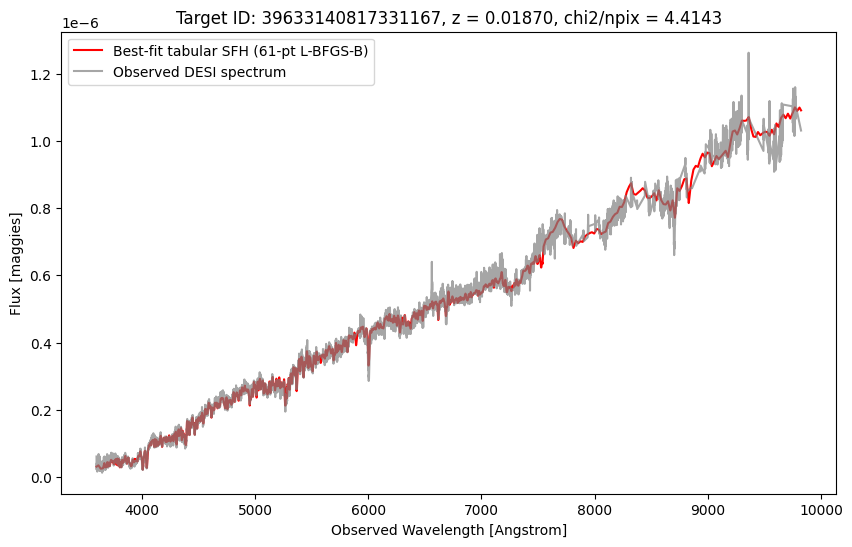

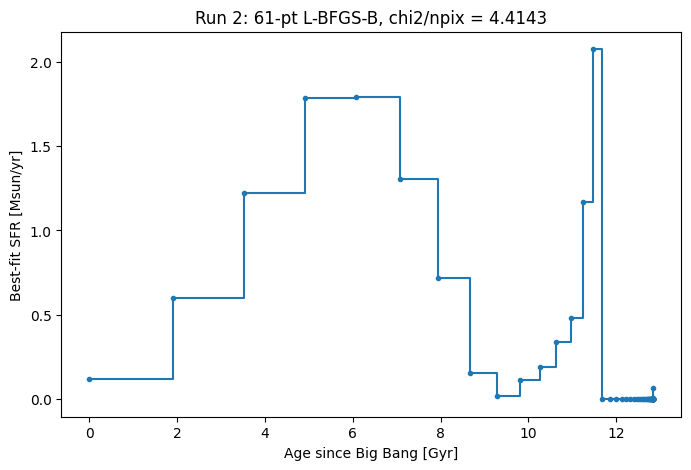

In [20]:
model_run2 = model_maggies(res_dense.x, age_dense)

plt.figure(figsize=(10, 6))
plt.plot(WAVE_OBS, model_run2, label='Best-fit tabular SFH (61-pt L-BFGS-B)', color='red')
plt.plot(WAVE_OBS[good], flux[good], label='Observed DESI spectrum', color='gray', alpha=0.7)
plt.xlabel('Observed Wavelength [Angstrom]')
plt.ylabel('Flux [maggies]')
plt.title(f'Target ID: {TARGETID}, z = {z:.5f}, chi2/npix = {res_dense.fun/good.sum():.4f}')
plt.legend()
plt.savefig('figures/run2_61pt_lbfgsb_bestfit.png', dpi=150, bbox_inches='tight')

plt.figure(figsize=(8, 5))
plt.step(age_dense, res_dense.x, where='post', marker='o', ms=3)
plt.xlabel('Age since Big Bang [Gyr]')
plt.ylabel('Best-fit SFR [Msun/yr]')
plt.title(f'Run 2: 61-pt L-BFGS-B, chi2/npix = {res_dense.fun/good.sum():.4f}')
plt.savefig('figures/run2_61pt_lbfgsb_sfr.png', dpi=150, bbox_inches='tight')


In [21]:
from scipy.optimize import nnls

n = len(age_dense)
A = np.zeros((good.sum(), n))   # design matrix: one column per age-point "basis" SFH

for i in range(n):
    e_i = np.zeros(n)
    e_i[i] = 1.0
    A[:, i] = model_maggies(e_i, age_dense)[good]

# weighted NNLS = chi2-minimizing NNLS: pre-multiply rows by sqrt(ivar)
w = np.sqrt(ivm[good])
sfr_lin, resid_norm = nnls(A * w[:, None], flux[good] * w)

chi2_lin = resid_norm**2
print(f"chi2={chi2_lin:.2f}, chi2/npix={chi2_lin/good.sum():.4f}")

chi2=25664.50, chi2/npix=4.3946


/var/folders/4v/k4xpjdyx3f1_c95lc_dlyhkr0000gq/T/ipykernel_48643/3114322468.py:3: RuntimeWarning: divide by zero encountered in divide
  resid = (flux - model_lin) / unc


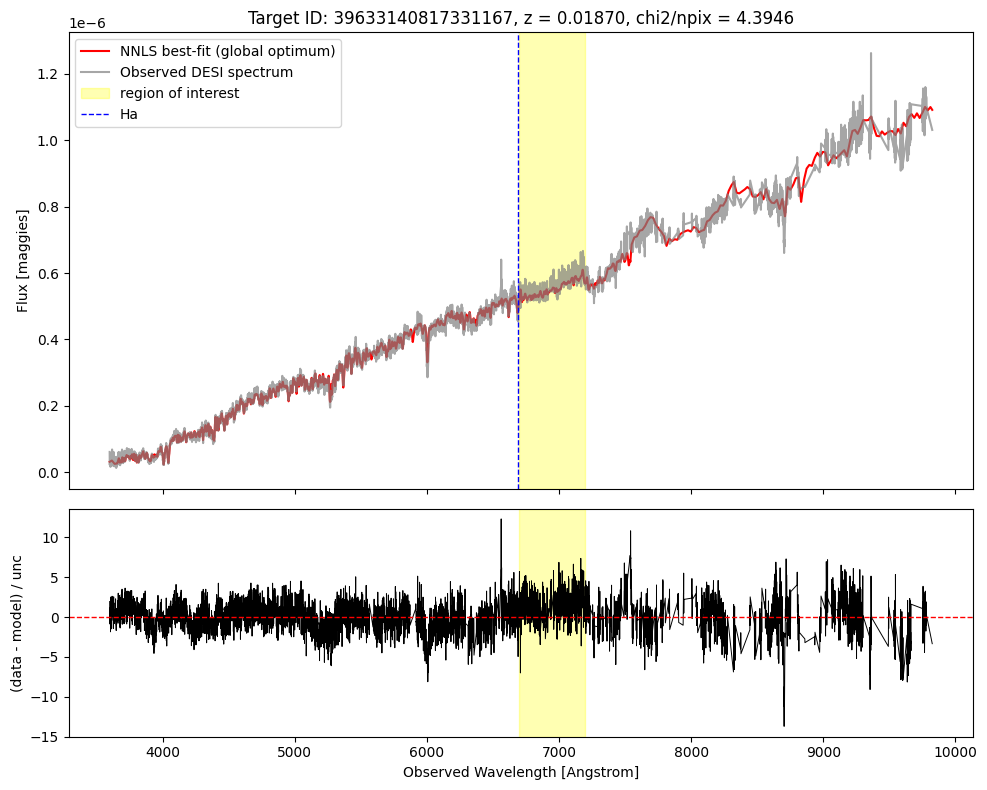

In [22]:
model_lin = model_maggies(sfr_lin, age_dense)

resid = (flux - model_lin) / unc

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(WAVE_OBS, model_lin, color='red', label='NNLS best-fit (global optimum)')
ax1.plot(WAVE_OBS[good], flux[good], color='gray', alpha=0.7, label='Observed DESI spectrum')
ax1.axvspan(6700, 7200, color='yellow', alpha=0.3, label='region of interest')

ax1.axvline(6687.4, color='blue', ls='--', lw=1, label='Ha')
ax1.set_ylabel('Flux [maggies]')
ax1.legend()
ax1.set_title(f'Target ID: {TARGETID}, z = {z:.5f}, chi2/npix = {chi2_lin/good.sum():.4f}')

ax2.plot(WAVE_OBS[good], resid[good], color='black', lw=0.7)
ax2.axhline(0, color='red', ls='--', lw=1)
ax2.axvspan(6700, 7200, color='yellow', alpha=0.3)
ax2.set_ylabel('(data - model) / unc')
ax2.set_xlabel('Observed Wavelength [Angstrom]')

plt.tight_layout()
plt.savefig('figures/run3_61pt_nnls_bestfit.png', dpi=150, bbox_inches='tight')


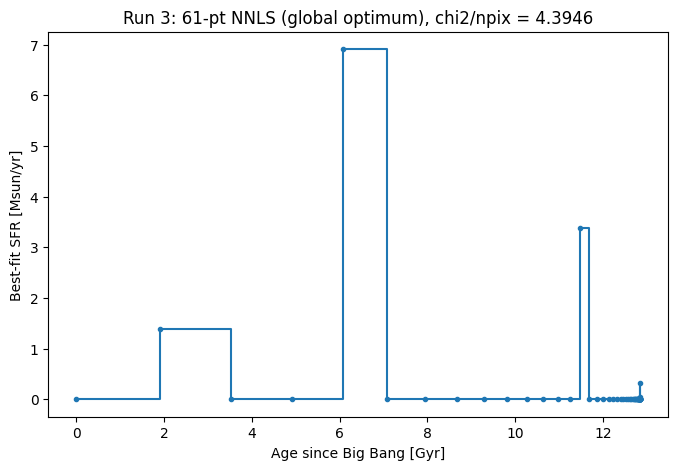

In [23]:
plt.figure(figsize=(8, 5))
plt.step(age_dense, sfr_lin, where='post', marker='o', ms=3)
plt.xlabel('Age since Big Bang [Gyr]')
plt.ylabel('Best-fit SFR [Msun/yr]')
plt.title(f'Run 3: 61-pt NNLS (global optimum), chi2/npix = {chi2_lin/good.sum():.4f}')
plt.savefig('figures/run3_61pt_nnls_sfr.png', dpi=150, bbox_inches='tight')


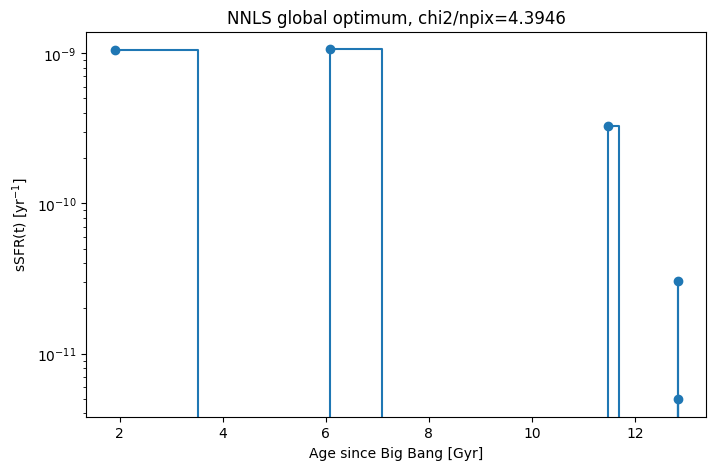

In [24]:
plot_ssfr(age_dense, sfr_lin, title=f"NNLS global optimum, chi2/npix={chi2_lin/good.sum():.4f}")

in-band  mean resid = 1.510, median = 1.499, n=568
out-band mean resid = -0.090, median = 0.003, n=5272


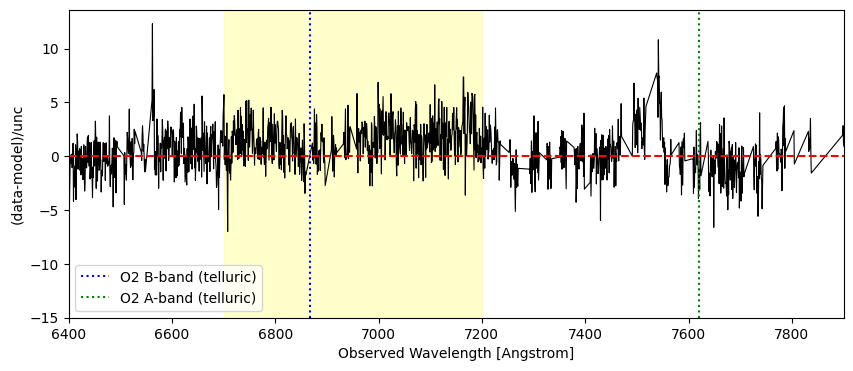

In [25]:
inband = (WAVE_OBS >= 6700) & (WAVE_OBS <= 7200) & good
outband = ~((WAVE_OBS >= 6700) & (WAVE_OBS <= 7200)) & good

print(f"in-band  mean resid = {resid[inband].mean():.3f}, median = {np.median(resid[inband]):.3f}, n={inband.sum()}")
print(f"out-band mean resid = {resid[outband].mean():.3f}, median = {np.median(resid[outband]):.3f}, n={outband.sum()}")



plt.figure(figsize=(10,4))
plt.plot(WAVE_OBS[good], resid[good], 'k-', lw=0.8)
plt.axvline(6867, color='blue', ls=':', label='O2 B-band (telluric)')
plt.axvline(7620, color='green', ls=':', label='O2 A-band (telluric)')
plt.axvspan(6700, 7200, color='yellow', alpha=0.2)
plt.axhline(0, color='red', ls='--')
plt.xlim(6400, 7900)
plt.xlabel('Observed Wavelength [Angstrom]')
plt.ylabel('(data-model)/unc')
plt.legend()

in-band mean resid before: 1.510
in-band mean resid after:  1.410


/var/folders/4v/k4xpjdyx3f1_c95lc_dlyhkr0000gq/T/ipykernel_48643/2162899547.py:23: RuntimeWarning: divide by zero encountered in divide
  resid_with_lines = (flux - model_with_lines) / unc


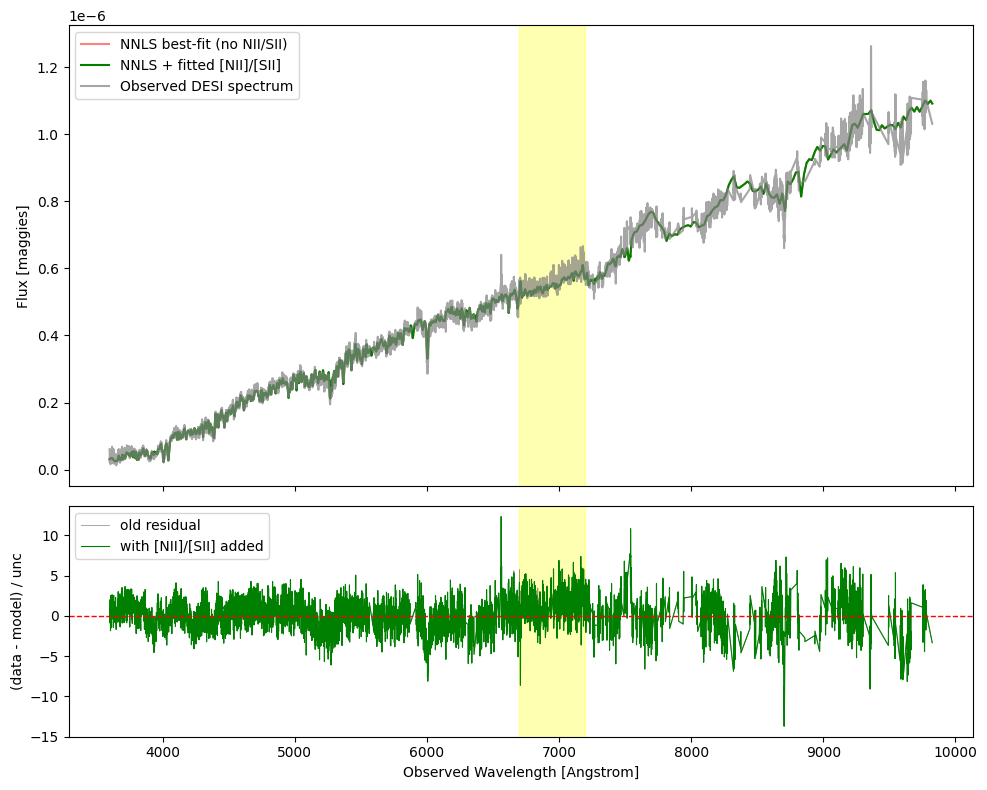

In [26]:
from hubersed.conversion import flambda_to_maggies

c_kms = 299792.458
vshift = -194.68987   # km/s, shared by all narrow lines (FastSpecFit)
sigma_kms = 266.5066   # km/s, shared

lines = [
    dict(rest_vac=6548.05, amp=1.2884959),   # [N II] 6548
    dict(rest_vac=6585.269, amp=3.7904847),  # [N II] 6584
    dict(rest_vac=6718.294, amp=3.1102748),  # [S II] 6716
    dict(rest_vac=6732.678, amp=5.273663e-07),  # [S II] 6731, ~0
]

line_flambda = np.zeros_like(WAVE_OBS)  # 1e-17 erg/s/cm^2/A units, same as FastSpecFit AMP
for ln in lines:
    center = ln['rest_vac'] * (1 + z) * (1 + vshift / c_kms)
    sigma_A = (sigma_kms / c_kms) * center
    line_flambda += ln['amp'] * np.exp(-0.5 * ((WAVE_OBS - center) / sigma_A) ** 2)

line_maggies = flambda_to_maggies(WAVE_OBS, line_flambda)

model_with_lines = model_lin + line_maggies
resid_with_lines = (flux - model_with_lines) / unc

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                                 gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(WAVE_OBS, model_lin, color='red', alpha=0.5, label='NNLS best-fit (no NII/SII)')
ax1.plot(WAVE_OBS, model_with_lines, color='green', label='NNLS + fitted [NII]/[SII]')
ax1.plot(WAVE_OBS[good], flux[good], color='gray', alpha=0.7, label='Observed DESI spectrum')
ax1.axvspan(6700, 7200, color='yellow', alpha=0.3)
ax1.set_ylabel('Flux [maggies]')
ax1.legend()

ax2.plot(WAVE_OBS[good], resid[good], color='black', lw=0.6, alpha=0.4, label='old residual')
ax2.plot(WAVE_OBS[good], resid_with_lines[good], color='green', lw=0.8, label='with [NII]/[SII] added')
ax2.axhline(0, color='red', ls='--', lw=1)
ax2.axvspan(6700, 7200, color='yellow', alpha=0.3)
ax2.set_ylabel('(data - model) / unc')
ax2.set_xlabel('Observed Wavelength [Angstrom]')
ax2.legend()
plt.tight_layout()

inband = (WAVE_OBS >= 6700) & (WAVE_OBS <= 7200) & good
print(f"in-band mean resid before: {resid[inband].mean():.3f}")
print(f"in-band mean resid after:  {resid_with_lines[inband].mean():.3f}")

In [27]:
AV_fsf = 0.31388634
dust2_fsf = AV_fsf / 1.086   # invert A_V ~ 1.086 * tau_V
dust1_fsf = dust2_fsf * dust_ratio   # keep the same dust1/dust2 ratio as before

sp.params["dust2"] = dust2_fsf
sp.params["dust1"] = dust1_fsf

n = len(age_dense)
A_fsf = np.zeros((good.sum(), n))
for i in range(n):
    e_i = np.zeros(n)
    e_i[i] = 1.0
    A_fsf[:, i] = model_maggies(e_i, age_dense)[good]

w = np.sqrt(ivm[good])
sfr_fsf, resid_norm = nnls(A_fsf * w[:, None], flux[good] * w)
chi2_fsf = resid_norm**2
print(f"dust2={dust2_fsf:.4f} (AV={AV_fsf:.3f}), chi2={chi2_fsf:.2f}, chi2/npix={chi2_fsf/good.sum():.4f}")

dust2=0.2890 (AV=0.314), chi2=30862.56, chi2/npix=5.2847


In [28]:
def chi2_given_dust(params):
    dust2_val, dust_index_val, dust_ratio_val = params
    if dust2_val < 0 or dust_ratio_val < 0:
        return 1e12
    sp.params["dust2"] = dust2_val
    sp.params["dust1"] = dust2_val * dust_ratio_val
    sp.params["dust_index"] = dust_index_val

    A = np.zeros((good.sum(), n))
    for i in range(n):
        e_i = np.zeros(n)
        e_i[i] = 1.0
        A[:, i] = model_maggies(e_i, age_dense)[good]

    _, resid_norm = nnls(A * w[:, None], flux[good] * w)
    return resid_norm**2

x0 = [dust2_fsf, -2.32386258, dust_ratio]
res_dust = minimize(chi2_given_dust, x0, method='Nelder-Mead',
                     options={'xatol': 1e-3, 'fatol': 1.0, 'maxiter': 200})

print(f"best dust2={res_dust.x[0]:.4f}, dust_index={res_dust.x[1]:.4f}, dust_ratio={res_dust.x[2]:.4f}")
print(f"chi2={res_dust.fun:.2f}, chi2/npix={res_dust.fun/good.sum():.4f}")

best dust2=0.1381, dust_index=-2.1036, dust_ratio=0.0000
chi2=25624.11, chi2/npix=4.3877


In [29]:
# reset to original MAP dust/gas params, only change sigma_smooth
sp.params["dust2"] = 0.13165773
sp.params["dust1"] = 0.13165773 * 0.87079155
sp.params["dust_index"] = -2.32386258
sp.params["logzsol"] = 0.24999979
sp.params["gas_logz"] = 0.32816795
sp.params["gas_logu"] = -3.40446795
sp.params["sigma_smooth"] = 207.16   # FastSpecFit's VDISP, replacing the old MAP's 151.33

n = len(age_dense)
A_sig = np.zeros((good.sum(), n))
for i in range(n):
    e_i = np.zeros(n)
    e_i[i] = 1.0
    A_sig[:, i] = model_maggies(e_i, age_dense)[good]

w = np.sqrt(ivm[good])
sfr_sig, resid_norm = nnls(A_sig * w[:, None], flux[good] * w)
chi2_sig = resid_norm**2
print(f"sigma_smooth=207.16, chi2={chi2_sig:.2f}, chi2/npix={chi2_sig/good.sum():.4f}")

sigma_smooth=207.16, chi2=25691.02, chi2/npix=4.3991


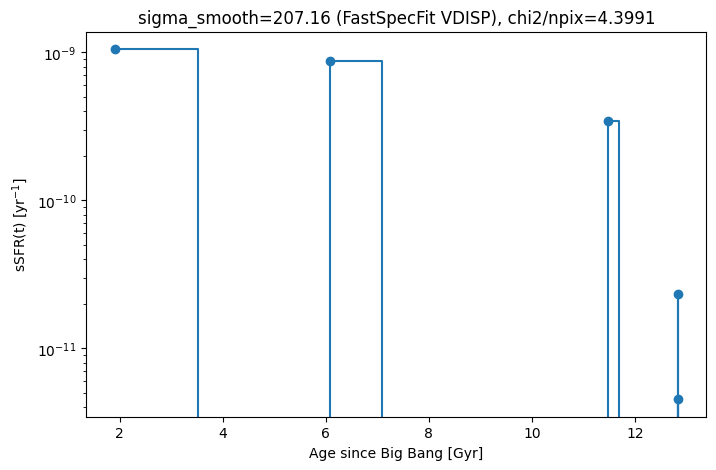

In [30]:
plot_ssfr(age_dense, sfr_sig, title=f"sigma_smooth=207.16 (FastSpecFit VDISP), chi2/npix={chi2_sig/good.sum():.4f}")


In [31]:
sp.params["dust2"] = 0.13165773
sp.params["dust1"] = 0.13165773 * 0.87079155
sp.params["dust_index"] = -2.32386258
sp.params["logzsol"] = 0.24999979
sp.params["gas_logz"] = 0.32816795
sp.params["gas_logu"] = -3.40446795
sp.params["sigma_smooth"] = 151.33225551   # back to the value that actually did best

sp.params["imf_type"] = 3   # Salpeter (1955) -- bottom-heavy vs default Kroupa (imf_type=2)

n = len(age_dense)
A_imf = np.zeros((good.sum(), n))
for i in range(n):
    e_i = np.zeros(n)
    e_i[i] = 1.0
    A_imf[:, i] = model_maggies(e_i, age_dense)[good]

w = np.sqrt(ivm[good])
sfr_imf, resid_norm = nnls(A_imf * w[:, None], flux[good] * w)
chi2_imf = resid_norm**2
print(f"imf_type=0 (Salpeter), chi2={chi2_imf:.2f}, chi2/npix={chi2_imf/good.sum():.4f}")

imf_type=0 (Salpeter), chi2=25753.83, chi2/npix=4.4099


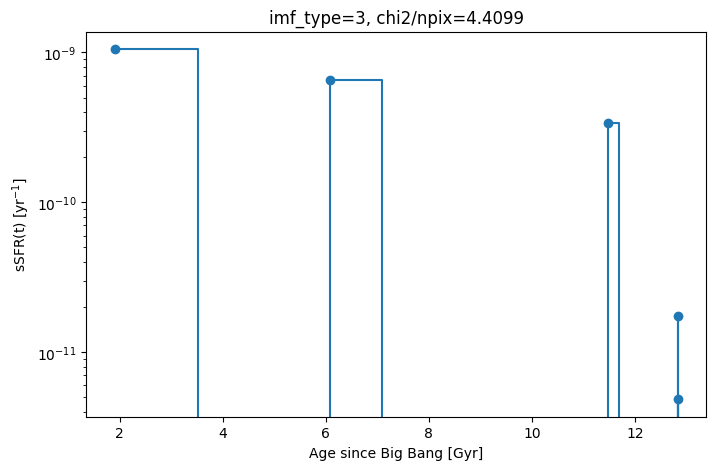

In [32]:
plot_ssfr(age_dense, sfr_imf, title=f"imf_type=3, chi2/npix={chi2_imf/good.sum():.4f}")


In [33]:
# reset sp to the Kroupa/best-baseline settings (previous cells mutated sp.params in place)
sp.params["imf_type"] = 2   # Kroupa, back to default
sp.params["dust2"] = 0.13165773
sp.params["dust1"] = 0.13165773 * 0.87079155
sp.params["dust_index"] = -2.32386258
sp.params["logzsol"] = 0.24999979
sp.params["gas_logz"] = 0.32816795
sp.params["gas_logu"] = -3.40446795
sp.params["sigma_smooth"] = 151.33225551

model_lin = model_maggies(sfr_lin, age_dense)   # sfr_lin = best NNLS result, chi2/npix=4.3946
resid_raw = flux - model_lin

region = (WAVE_OBS >= 4200) & (WAVE_OBS <= 4600) & good
actual_std = np.std(resid_raw[region])
predicted_std = np.median(1 / np.sqrt(ivm[region]))

print(f"n pixels in 4200-4600A region: {region.sum()}")
print(f"actual scatter of (data-model): {actual_std:.4e}")
print(f"formal uncertainty (median 1/sqrt(ivar)): {predicted_std:.4e}")
print(f"ratio (actual/formal): {actual_std/predicted_std:.3f}")
print(f"implied chi2/npix if this ratio holds everywhere: {(actual_std/predicted_std)**2:.3f}")

n pixels in 4200-4600A region: 501
actual scatter of (data-model): 7.6446e-09
formal uncertainty (median 1/sqrt(ivar)): 5.0286e-09
ratio (actual/formal): 1.520
implied chi2/npix if this ratio holds everywhere: 2.311
